In [2]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("seaborn", sns.__version__)
print("ready ")

numpy 2.5.3
pandas 3.0.5
seaborn 0.13.2
ready 


In [3]:
# load the three raw World Bank CSVs
beds = pd.read_csv("../data/hospital_beds.csv", skiprows=4)
phys = pd.read_csv("../data/physicians.csv", skiprows=4)
life = pd.read_csv("../data/life_expectancy.csv", skiprows=4)

# quick peek at one of them
print("shape:", beds.shape)
beds.head()

shape: (265, 71)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,1.973383,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,0.170627,NaN,NaN,NaN,NaN,NaN,...,0.42,0.4,0.38,0.33,0.36,0.36,0.35,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,0.786552,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,2.061462,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# grab only the year columns
year_cols = [c for c in beds.columns if str(c).isdigit()]

# reshape wide → long (one row per country-year)
def to_long(df, indicator):
    long = df.melt(
        id_vars=["Country Name", "Country Code"],
        value_vars=year_cols,
        var_name="year",
        value_name=indicator,
    )
    return long.dropna(subset=[indicator])

# apply to all three files
beds_long = to_long(beds, "beds_per_1000")
phys_long = to_long(phys, "physicians_per_1000")
life_long = to_long(life, "life_expectancy")

# check row counts
print("beds rows:", len(beds_long))
print("phys rows:", len(phys_long))
print("life rows:", len(life_long))

beds_long.head()

beds rows: 5858
phys rows: 5529
life rows: 17126


,Country Name,Country Code,year,beds_per_1000
1,Africa Eastern and Southern,AFE,1960,1.973383
2,Afghanistan,AFG,1960,0.170627
3,Africa Western and Central,AFW,1960,0.786552
4,Angola,AGO,1960,2.061462
5,Albania,ALB,1960,5.102676


In [5]:
# world bank region/aggregate codes (not real countries)
regions = {
    "AFE","AFW","ARB","CEB","CSS","EAP","EAS","ECA","ECS","EMU",
    "EUU","FCS","HIC","HPC","IBD","IBT","IDA","IDB","IDX","INX",
    "LAC","LCN","LDC","LIC","LMC","LMY","LTE","MIC","MNA","NAC",
    "OED","OSS","PRE","PSS","PST","SSA","SSF","SST","TEA","TEC",
    "TLA","TMN","TSA","TSS","UMC","WLD",
}

def only_countries(df):
    return df[~df["Country Code"].isin(regions)].copy()

beds_long = only_countries(beds_long)
phys_long = only_countries(phys_long)
life_long = only_countries(life_long)

print("beds:", len(beds_long))
print("phys:", len(phys_long))
print("life:", len(life_long))

beds: 4801
phys: 5367
life: 14266


In [6]:
# connect to sqlite database
conn = sqlite3.connect("../data/nepal_health.db")

# save our 3 dataframes as tables
beds_long.to_sql("beds", conn, index=False, if_exists="replace")
phys_long.to_sql("physicians", conn, index=False, if_exists="replace")
life_long.to_sql("life_expectancy", conn, index=False, if_exists="replace")

# check tables
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)

,name
0,beds
1,physicians
2,life_expectancy


In [7]:
# look at 5 rows from the beds table
pd.read_sql("SELECT * FROM beds LIMIT 5", conn)

,Country Name,Country Code,year,beds_per_1000
0,Afghanistan,AFG,1960,0.170627
1,Angola,AGO,1960,2.061462
2,Albania,ALB,1960,5.102676
3,Argentina,ARG,1960,6.352251
4,Antigua and Barbuda,ATG,1960,7.706422


In [8]:
# nepal's hospital beds, sorted by year
query = """
SELECT year, beds_per_1000
FROM beds
WHERE "Country Code" = 'NPL'
ORDER BY year
"""
nepal_beds = pd.read_sql(query, conn)
nepal_beds.head(10)

,year,beds_per_1000
0,1960,0.115764
1,1970,0.135300
2,1975,0.137700
3,1980,0.175600
4,1985,0.180200
5,1987,0.227000
6,1988,0.239800
7,1989,0.244300
8,1990,0.243600
9,1991,0.237200


In [9]:
query = """
SELECT year, beds_per_1000
FROM beds
WHERE "Country Code" = 'NPL'
ORDER BY year DESC
"""
pd.read_sql(query, conn).head(10)

,year,beds_per_1000
0,2023,0.54
1,2022,0.53
2,2021,0.39
3,2020,0.28
4,2019,0.29
5,2018,0.29
6,2017,0.29
7,2016,0.28
8,2015,0.25
9,2014,0.27


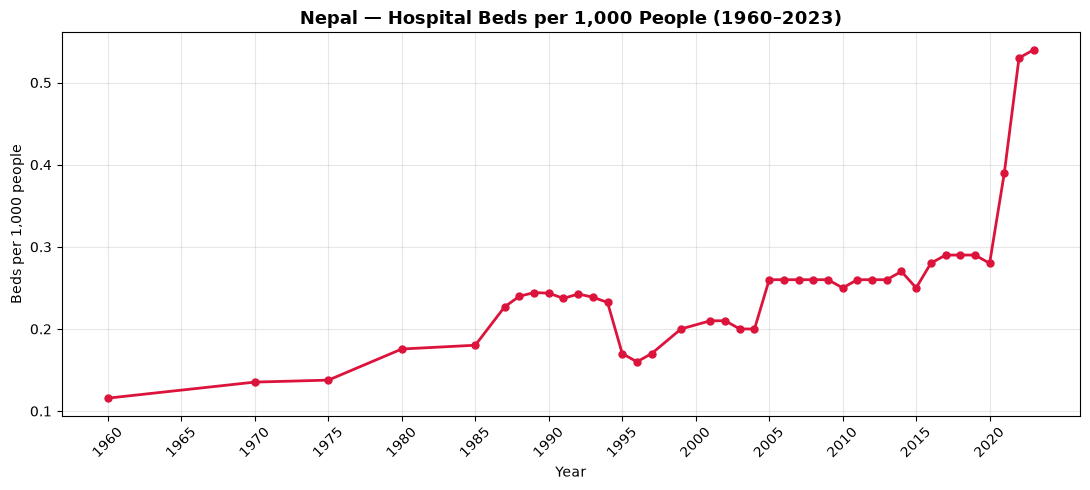

In [11]:
plt.figure(figsize=(11, 5))
plt.plot(nepal["year"], nepal["beds_per_1000"],
         marker="o", markersize=5, linewidth=2, color="crimson")

plt.title("Nepal — Hospital Beds per 1,000 People (1960–2023)", fontsize=13, weight="bold")
plt.xlabel("Year")
plt.ylabel("Beds per 1,000 people")
plt.xticks(range(1960, 2025, 5), rotation=45)
plt.grid(alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()

# SAVE first
plt.savefig("../visuals/nepal_beds.png", dpi=150, bbox_inches="tight")

# THEN show
plt.show()